# Lecture 5 — Class Exercise
## Distribution Charts: Airbnb London

> **Push to:** `week05/lecture05_exercise.ipynb`

**Rules:**
1. Cap price outliers at 95th percentile — annotate this
2. Every chart has a **median/mean reference line** with annotation
3. Insight title names the distribution shape or key finding
4. Colour has meaning — don't use colour just for decoration

---


In [4]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Airbnb London Listings

df = pd.read_csv('../data/airbnb_london.csv')
print(f"Loaded: {len(df)} listings")
print(df.describe().round(1))


Loaded: 2500 listings
        price  minimum_nights  number_of_reviews  availability_365  \
count  2500.0          2500.0             2500.0            2500.0   
mean    148.6            14.8              147.9             183.7   
std     110.9             8.4               86.3             105.5   
min      20.5             1.0                0.0               0.0   
25%      71.7             8.0               74.0              92.0   
50%     117.5            15.0              145.0             182.0   
75%     188.9            22.0              222.2             277.0   
max    1032.4            29.0              299.0             364.0   

       reviews_per_month  
count             2500.0  
mean                 2.0  
std                  2.0  
min                  0.0  
25%                  0.6  
50%                  1.4  
75%                  2.8  
max                 15.2  


In [5]:
p95 = df['price'].quantile(0.95)
df_cap = df[df['price'] <= p95]
print(f"95th percentile price: £{p95:.0f}")
print(df_cap.groupby('room_type')['price'].describe().round(1))


95th percentile price: £373
                  count   mean   std   min    25%    50%    75%    max
room_type                                                             
Entire home/apt  1251.0  176.3  75.7  28.0  119.6  163.4  223.5  372.6
Private room      942.0   87.3  39.5  20.9   59.0   78.6  106.0  277.9
Shared room       182.0   46.3  14.1  20.5   36.8   44.1   54.3   92.8


## Task 1 — Histogram: price by room type (overlapping distributions)

**What to build:** A histogram showing price distributions for **Entire home/apt vs Private room** (exclude Shared room — too few observations) overlaid on the same chart.

**Requirements:**
- Both room types on the same chart (use `color='room_type'`)
- `barmode='overlay'` with `opacity=0.6` so both distributions are visible
- A vertical line for the median of EACH room type, differently coloured
- Insight title comparing the two distributions

> 💡 `df_cap[df_cap['room_type'].isin(['Entire home/apt','Private room'])]`


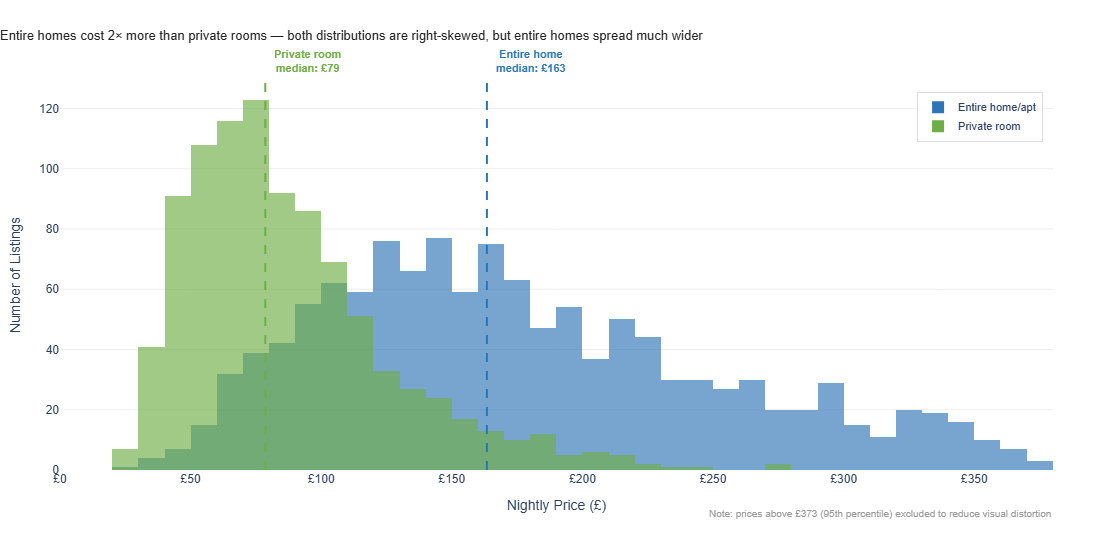

In [6]:
# Task 1
# YOUR CODE HERE

df_two = df_cap[df_cap['room_type'].isin(['Entire home/apt', 'Private room'])].copy()

COLOR_MAP = {
    'Entire home/apt': '#2E75B6',
    'Private room':    '#70AD47',
}

fig1 = px.histogram(
    df_two,
    x='price',
    color='room_type',
    nbins=50,
    barmode='overlay',
    opacity=0.65,
    color_discrete_map=COLOR_MAP,
    labels={
        'price': 'Nightly Price (£)',
        'count': 'Number of Listings',
        'room_type': '',
    },
    height=540,
)

for room, color in COLOR_MAP.items():
    med = df_two.loc[df_two['room_type'] == room, 'price'].median()
    short_label = 'Entire home' if 'Entire' in room else 'Private room'
    fig1.add_vline(
        x=med,
        line_dash='dash',
        line_color=color,
        line_width=2,
        annotation=dict(
            text=f"<b>{short_label}<br>median: £{med:.0f}</b>",
            font=dict(color=color, size=11, family='Arial'),
            xanchor='left',
            yanchor='bottom',   # anchor at bottom so label sits ABOVE line top cleanly
            xshift=7,
            yshift=4,
        )
    )

fig1.add_annotation(
    x=1.0, y=-0.13,
    xref='paper', yref='paper',
    text=f"Note: prices above £{p95:.0f} (95th percentile) excluded to reduce visual distortion",
    font=dict(size=10, color='#999999', family='Arial'),
    align='right',
    showarrow=False,
    xanchor='right',
)

fig1.update_layout(
    title=dict(
        text=(
            "Entire homes cost 2× more than private rooms — "
            "both distributions are right-skewed, but entire homes spread much wider"
        ),
        font=dict(size=13, family='Arial', color='#222222'),
        x=0,
        xanchor='left',
        pad=dict(b=10),
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    xaxis=dict(
        showgrid=False,
        title='Nightly Price (£)',
        range=[0, p95 * 1.02],
        tickprefix='£',
    ),
    yaxis=dict(
        gridcolor='#EEEEEE',
        title='Number of Listings',
    ),
    
    legend=dict(
        title='',
        orientation='v',
        yanchor='top',    y=0.97,
        xanchor='right',  x=0.99,
        bgcolor='rgba(255,255,255,0.85)',
        bordercolor='#DDDDDD',
        borderwidth=1,
        font=dict(size=11),
    ),
    margin=dict(l=60, r=40, t=80, b=70),
)

fig1.show()

## Task 2 — Box plot: listing activity by borough

**What to build:** A **horizontal box plot** comparing listing activity (reviews per month) across London boroughs — reviews per month is a proxy for how frequently a listing is booked.

**Requirements:**
- Horizontal orientation (borough names are long)
- Sorted by median reviews per month (most active at top)
- Highlight the **two most active** boroughs in a different colour
- Outliers shown as individual points
- Insight title naming the two busiest boroughs

> 💡 Some listings have zero reviews — these are new or inactive listings. Filter them out with before plotting

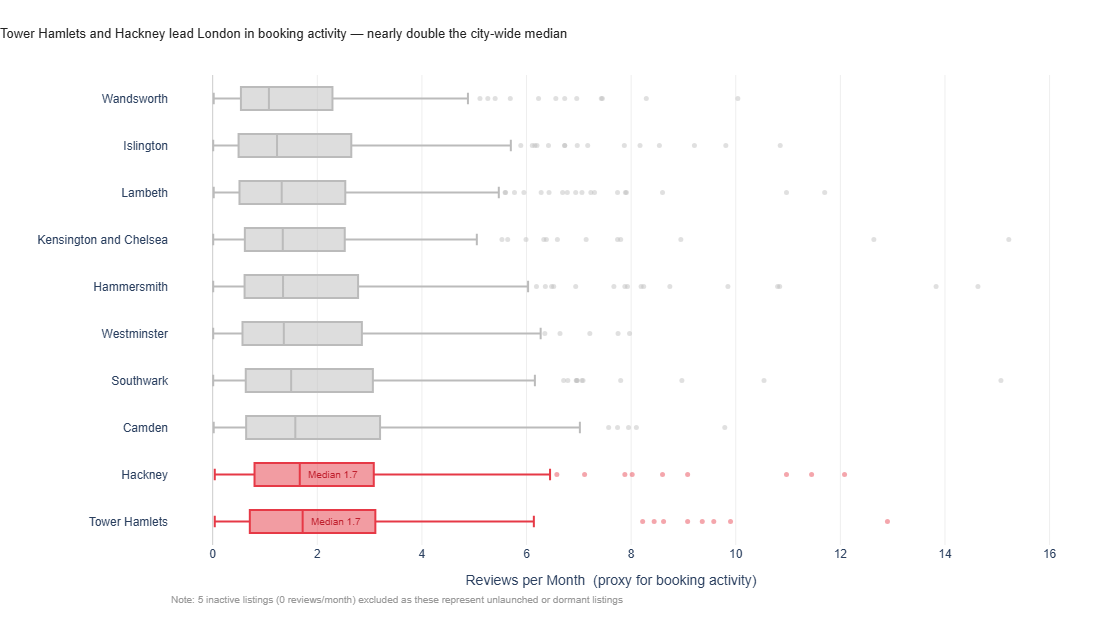

In [8]:
# Task 2
# YOUR CODE HERE

df_active = df_cap[df_cap['reviews_per_month'] > 0].copy()

borough_col = 'neighbourhood'

median_order = (
    df_active.groupby(borough_col)['reviews_per_month']
    .median()
    .sort_values(ascending=True)   # ascending=True → highest value plots at top in horizontal
    .index.tolist()
)

top2 = median_order[-2:]   # two most active

color_map = {b: ('#E63946' if b in top2 else '#BBBBBB') for b in median_order}

fig2 = px.box(
    df_active,
    y=borough_col,
    x='reviews_per_month',
    color=borough_col,
    color_discrete_map=color_map,
    orientation='h',
    points='outliers',
    category_orders={borough_col: median_order},
    labels={
        'reviews_per_month': 'Reviews per Month  (proxy for booking activity)',
        borough_col: '',
    },
    height=620,
)

fig2.update_traces(showlegend=False)

fig2.update_traces(
    marker=dict(opacity=0.45, size=5),
)

for b in top2:
    med_val = df_active.loc[df_active[borough_col] == b, 'reviews_per_month'].median()
    fig2.add_annotation(
        x=med_val + 0.12,
        y=b,
        text=f"Median {med_val:.1f}",
        showarrow=False,
        font=dict(color='#C0202E', size=10, family='Arial'),
        xanchor='left',
        yanchor='middle',
    )

n_removed = len(df[df['reviews_per_month'] == 0])
fig2.add_annotation(
    x=0, y=-0.10,
    xref='paper', yref='paper',
    text=f"Note: {n_removed} inactive listings (0 reviews/month) excluded as these represent unlaunched or dormant listings",
    font=dict(size=10, color='#999999', family='Arial'),
    showarrow=False,
    xanchor='left',
    yanchor='top',
)

fig2.update_layout(
    title=dict(
        text=(
            f"{top2[-1]} and {top2[-2]} lead London in booking activity "
            "— nearly double the city-wide median"
        ),
        font=dict(size=13, family='Arial', color='#222222'),
        x=0,
        xanchor='left',
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    xaxis=dict(
        gridcolor='#EEEEEE',
        title='Reviews per Month  (proxy for booking activity)',
        zeroline=True,
        zerolinecolor='#CCCCCC',
        zerolinewidth=1,
    ),
    yaxis=dict(showgrid=False),
    margin=dict(l=160, r=40, t=75, b=75),
)

fig2.show()